In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu

In [ ]:
PATH_SIGMA = "output/results_Fortmann/merge.h5ad"
PATH_AUTHOR = "input/Fortmann-Data/fortmann_full.h5ad"

SEUIL = 0.95

mk_mature = ['ITGB3', 'FCGR2A', 'CD40LG', 'ITGA2B', 'GP1BA', 'PF4', 'GP6', 'PPBP']
mono = ['S100A12', 'LST1', 'LGALS3', 'VCAN', 'S100A9', 'S100A8', 'FCGR3A', 'CTSS', 'CD14']
macro = ['FCGR1A', 'MRC1', 'CSF1R', 'CX3CR1', 'CCR2', 'CD163', 'AIF1', 'CD14', 'CD68', 'LYZ']
Tlympho = ['CD8B', 'CD3E', 'TRAC', 'CD4', 'CD3D', 'CD3G', 'CD8A']
Blympho = ['MS4A1', 'CD19', 'HLA-DRA', 'CD79B', 'PAX5', 'CD74', 'HLA-DQB1', 'CD79A']
neutro = ['S100A12', 'FCGR3B', 'LCN2', 'ELANE', 'S100A9', 'S100A8', 'CEACAM8', 'CXCL8', 'MPO', 'CTSG', 'PRTN3']

lineage_panels = {
    "Megakaryocyte markers": mk_mature,
    "Monocyte markers": mono,
    "Macrophage markers": macro,
    "Tlymphocyte markers": Tlympho,
    "Blymphocyte markers": Blympho,
    "Neutrophil markers": neutro,
}

gray_to_red = mcolors.LinearSegmentedColormap.from_list("gray_to_red", [(0.5, 0.5, 0.5), (1, 0, 0)])

## 1. Data loading

In [14]:
adata_sigma  = sc.read_h5ad(PATH_SIGMA)
adata_author = sc.read_h5ad(PATH_AUTHOR)

adata_sigma.obs_names = [re.sub(r"_fortmann.*", "", name) for name in adata_sigma.obs_names]

print(f"adata_sigma  : {adata_sigma.shape[0]:,} cells")
print(f"adata_author : {adata_author.shape[0]:,} cells")

adata_sigma  : 9,914 cells
adata_author : 317,562 cells


## 2. Build adata_sumry

In [15]:
adata_sumry = ad.AnnData(adata_author.X, var=adata_author.var)
adata_sumry.obs_names = adata_author.obs_names
adata_sumry.obsm["X_umap"] = adata_author.obsm["X_umap"]
adata_sumry.layers["raw"] = adata_author.X.copy()
adata_sumry.obs["celltype"] = adata_author.obs["clusters"]
adata_sumry.obs["disease"] = adata_author.obs["disease"]

adata_sumry.obs["score"] = 0.0
adata_sumry.obs.loc[adata_sigma.obs_names, "score"] = adata_sigma.obs["score"].values

for prob in [c for c in adata_sigma.obs.columns if c.startswith("proba_")]:
    adata_sumry.obs[prob] = 0.0
    adata_sumry.obs.loc[adata_sigma.obs_names, prob] = adata_sigma.obs[prob].values

sc.pp.normalize_total(adata_sumry, target_sum=1e6)
sc.pp.log1p(adata_sumry)
adata_sumry.layers["log1p"] = adata_sumry.X

## 3. SIGMA+ labeling

In [16]:
MK_found_by_sigma = adata_sumry.obs["score"] >= SEUIL
adata_sumry.obs["Identified by SIGMA"] = pd.Categorical(
    MK_found_by_sigma.astype(str), categories=["False", "True"], ordered=True)
adata_sumry.uns["Identified by SIGMA_colors"] = ["#808080", "#ff0000"]

mk_author = adata_sumry[adata_sumry.obs["celltype"] == "megakaryocytes"]

print(f"# MK : {np.sum(MK_found_by_sigma):,}")
print(f"% among all cells : {np.sum(MK_found_by_sigma)/adata_sumry.n_obs*100:.3f} %")
print(f"% among megakaryocytes' authors : {np.sum(MK_found_by_sigma)/mk_author.n_obs:.3%}")

# MK : 928
% among all cells : 0.292 %
% among megakaryocytes' authors : 22.201%


## 4. Prepare dataframes for C and D

In [6]:
mk_df = mk_author.to_df()
mk_df["identified"] = mk_author.obs["Identified by SIGMA"].values
mk_df["disease"]    = mk_author.obs["disease"].values
mk_df = mk_df[mk_df["disease"].isin(["covid", "healthy"])].copy()
mk_df["disease"] = mk_df["disease"].astype(str)
mk_df_melt = mk_df.melt(id_vars=["identified", "disease"], var_name="gene", value_name="expression")

mk_df_melt_s100 = mk_df_melt[
    mk_df_melt["gene"].isin(["S100A8", "S100A9"]) &
    mk_df_melt["disease"].isin(["covid", "healthy"]) &
    (mk_df_melt["identified"] == "True")
]
pvals_covid_healthy = {}
for gene, sub in mk_df_melt_s100.groupby("gene"):
    x = sub.loc[sub["disease"] == "covid",   "expression"]
    y = sub.loc[sub["disease"] == "healthy", "expression"]
    _, p = mannwhitneyu(x, y, alternative="greater")
    pvals_covid_healthy[gene] = p

## 5. Utility functions

In [18]:
def p_to_star(p):
    if p < 0.0001: return "****"
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return ""

def plot_A(ax):
    n, bins, _ = ax.hist(adata_sigma.obs["score"], bins=200, alpha=0.7)
    ax.set_xlabel("Score"); ax.set_ylabel("Number of cells", color='C0')
    ax.set_yscale("log"); ax.tick_params(axis='y', labelcolor='C0')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax2 = ax.twinx()
    cumsum_pct  = 100 * np.cumsum(n) / np.sum(n)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax2.plot(bin_centers, cumsum_pct, color='red', linewidth=2)
    ax2.set_ylabel("Cumulative percentage of cells (%)", color='red')
    ax2.set_ylim(min(cumsum_pct), 100); ax2.tick_params(axis='y', labelcolor='red')
    ax.axvline(SEUIL, color='black', linestyle='--', linewidth=1)
    ax.text(SEUIL-0.085, ax.get_ylim()[1]*0.85, str(SEUIL),
            color='black', ha='left', va='top', fontsize=14)
    ax.set_title("Distribution of SIGMA scores", fontsize=16)
    ax.tick_params(axis="both", labelsize=14); ax2.tick_params(axis="y", labelsize=14)

def plot_B(ax0, ax1):
    sc.pl.umap(adata_sumry, s=20, title="Author's cell type annotation", color="celltype",
               ax=ax0, legend_loc="on data", legend_fontsize=10, show=False)
    sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "False"], s=10,
               title="MK identified by SIGMA", color="Identified by SIGMA",
               ax=ax1, legend_loc=None, show=False)
    sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] == "True"], s=10,
               color="Identified by SIGMA", ax=ax1, legend_loc=None, show=False)
    sc.pl.umap(adata_sumry[adata_sumry.obs["Identified by SIGMA"] != "none"], s=0,
               color="Identified by SIGMA", ax=ax1, legend_loc="upper right", show=False)
    for a in [ax0, ax1]:
        a.set_xlabel("UMAP 1"); a.set_ylabel("UMAP 2")
        if a.get_legend() is not None:
            a.set_ylabel(None)
            a.get_legend().set_title(a.get_legend().get_title().get_text(), prop={"size": 12})
            for text in a.get_legend().get_texts(): text.set_fontsize(12)
        a.tick_params(labelbottom=False, labelleft=False)
        a.set_xticklabels([]); a.set_yticklabels([])
        a.xaxis.label.set_size(14); a.yaxis.label.set_size(14); a.title.set_size(16)

def compute_C():
    results = {}
    for panel_name, genes in lineage_panels.items():
        df = mk_df_melt.loc[mk_df_melt["gene"].isin(genes), ["gene", "identified", "expression"]].copy()
        df = df.dropna(subset=["expression"])
        df["identified"] = df["identified"].eq("True")
        mannwhit_res = {}
        for gene, sub in df.groupby("gene", sort=False):
            no_ident = sub.loc[~sub["identified"], "expression"].to_numpy()
            ident    = sub.loc[sub["identified"],  "expression"].to_numpy()
            U, p = mannwhitneyu(no_ident, ident,
                                alternative="less" if panel_name == "Megakaryocyte markers" else "greater")
            mannwhit_res[gene] = (U, p)
        mannwhit_df = (pd.DataFrame.from_dict(mannwhit_res, orient="index", columns=["U_stat", "p_value"])
                       .rename_axis("gene").reset_index())
        mannwhit_df["p_value_adj"] = multipletests(mannwhit_df["p_value"], method="fdr_bh")[1]
        plot_df = df.assign(identified=df["identified"].map({False: "False", True: "True"}))
        bar_top = plot_df.groupby(["gene", "identified"])["expression"].mean().groupby("gene").max()
        results[panel_name] = {"genes": genes, "plot_df": plot_df,
                               "mannwhit_df": mannwhit_df, "bar_top": bar_top}
    return results

def plot_C(axes, results):
    for cpt, (panel_name, r) in enumerate(results.items()):
        ax = axes[cpt]
        sns.barplot(data=r["plot_df"], x="gene", y="expression", hue="identified",
                    order=r["genes"], ax=ax, palette={"False": "#1f77b4", "True": "#ff7f0e"})
        for i, gene in enumerate(r["genes"]):
            pval = r["mannwhit_df"].loc[r["mannwhit_df"]["gene"] == gene, "p_value_adj"].values
            y0   = float(r["bar_top"].loc[gene])
            ax.text(i, y0 + 0.01*y0, p_to_star(pval), ha="center", va="bottom", fontsize=14)
        ax.set_ylim(0, ax.get_ylim()[1]+1); ax.set_xlabel(None)
        ax.set_ylabel("log1p-CPM", fontsize=14)
        ax.set_title(panel_name, fontsize=16)
        ax.tick_params(axis="y", labelsize=12)
        plt.setp(ax.get_xticklabels(), rotation=90, ha="right", fontsize=12)
        if cpt == 1:
            ax.legend(title="Megakaryocytes identified by SIGMA",
                      bbox_to_anchor=(0.5, 1.42), loc="upper center", ncol=2,
                      fontsize=12, title_fontsize=11)
        else:
            ax.get_legend().remove()

def plot_D(ax):
    sns.violinplot(data=mk_df_melt_s100, y="gene", x="expression", hue="disease",
                   palette={"covid": "#8A2BE2", "healthy": "#32CD32"},
                   split=True, gap=0.03, inner="quart", bw_adjust=0.3, ax=ax)
    y_order = [t.get_text() for t in ax.get_yticklabels()]
    x_min, x_max = 0, ax.get_xlim()[-1]
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("log1p-CPM", fontsize=14)
    ax.set_ylabel(None)
    for i, gene in enumerate(y_order):
        ax.text(x_max-0.4, i, p_to_star(pvals_covid_healthy.get(gene)),
                va="center", ha="left", fontsize=10)

## 6. Figure A - Score distribution

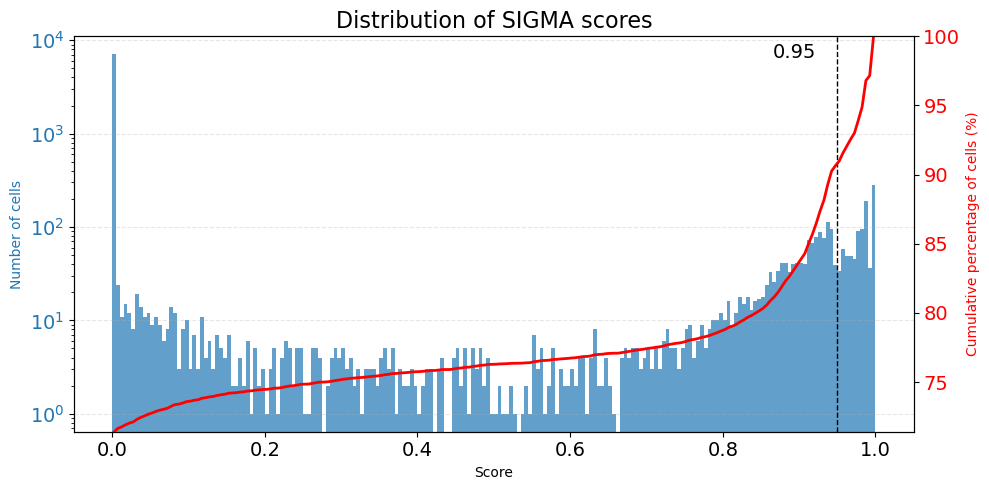

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_A(ax)
fig.tight_layout()
# fig.savefig("figures/fortmann-A.svg", bbox_inches="tight", dpi=500)
# fig.savefig("figures/fortmann-A.eps", bbox_inches="tight", dpi=500)
fig.savefig("figures/fortmann-A.pdf", bbox_inches="tight", dpi=500)
plt.show()

## 7. Figure B - UMAP

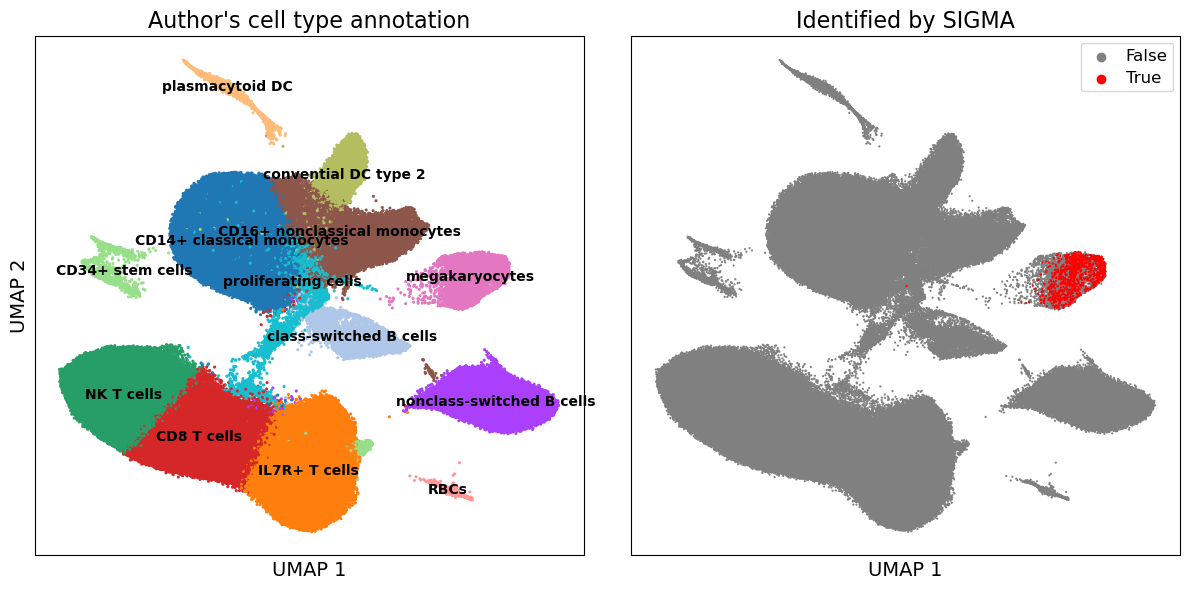

In [9]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
plot_B(ax[0], ax[1])
fig.tight_layout()
# fig.savefig("figures/fortmann-B.tiff", bbox_inches='tight', dpi=500)
# fig.savefig("figures/fortmann-B.eps", bbox_inches='tight', dpi=500)
fig.savefig("figures/fortmann-B.pdf", bbox_inches='tight', dpi=500)
plt.show()

## 8. Figure C - Lineage markers

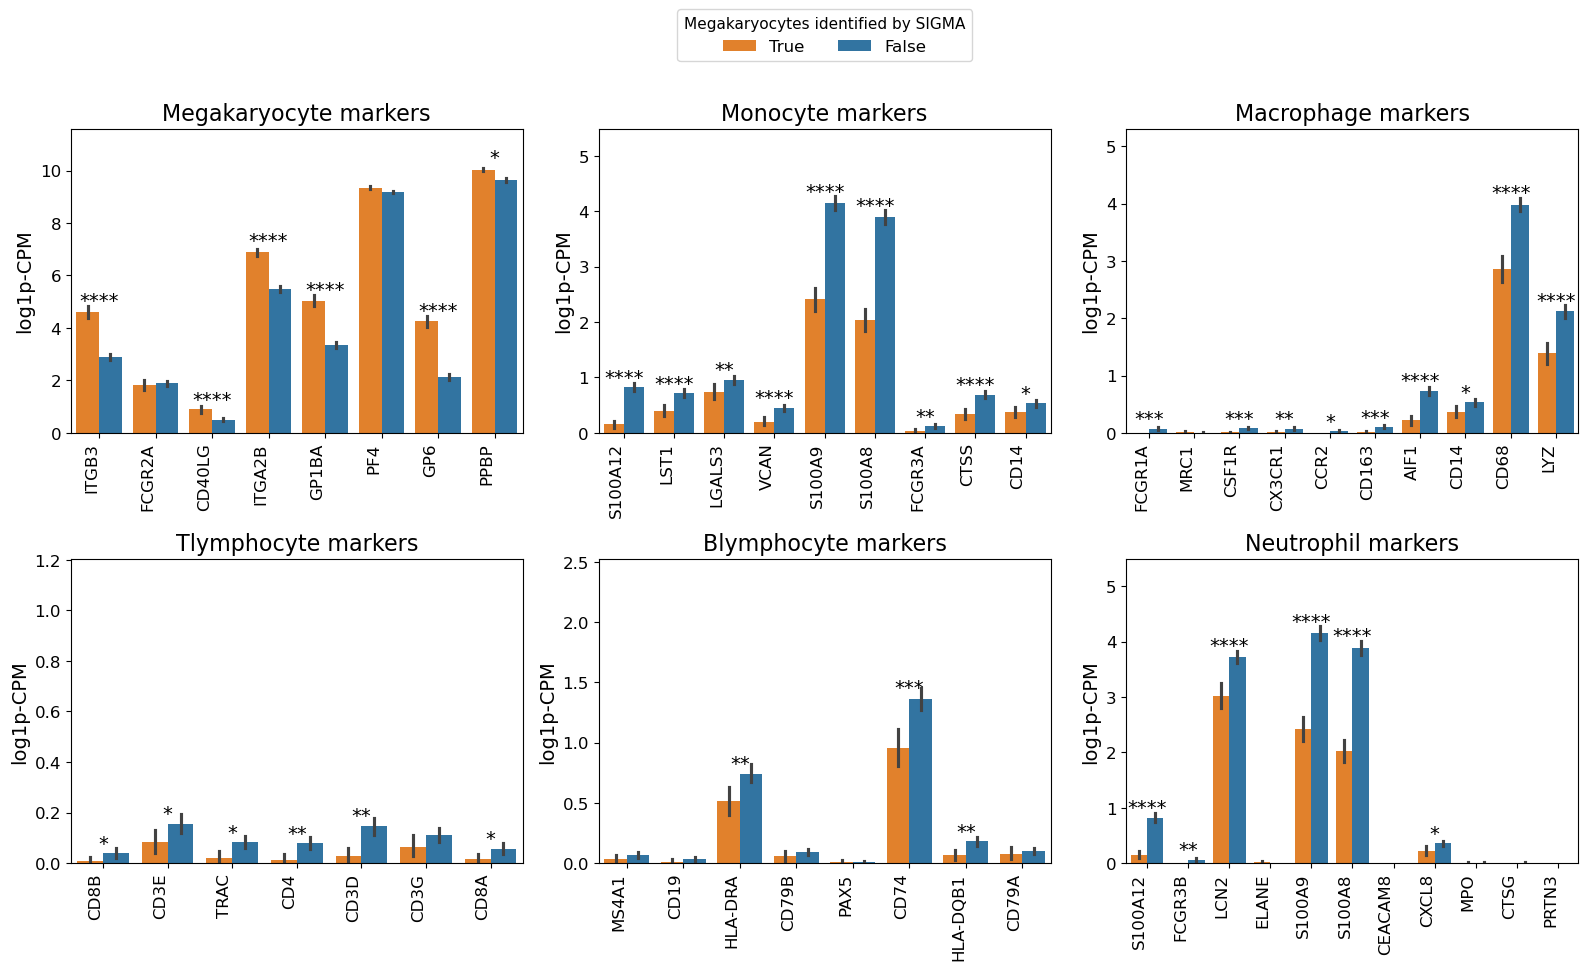

In [10]:
results_C = compute_C()

fig, ax = plt.subplots(2, 3, figsize=(16, 10))
plot_C(ax.flatten(), results_C)
fig.tight_layout()
# fig.savefig("figures/fortmann-C.svg", bbox_inches="tight", dpi=500)
# fig.savefig("figures/fortmann-C.eps", bbox_inches="tight", dpi=500)
fig.savefig("figures/fortmann-C.pdf", bbox_inches="tight", dpi=500)
plt.show()

## 9. Figure D - S100A8/9 violin

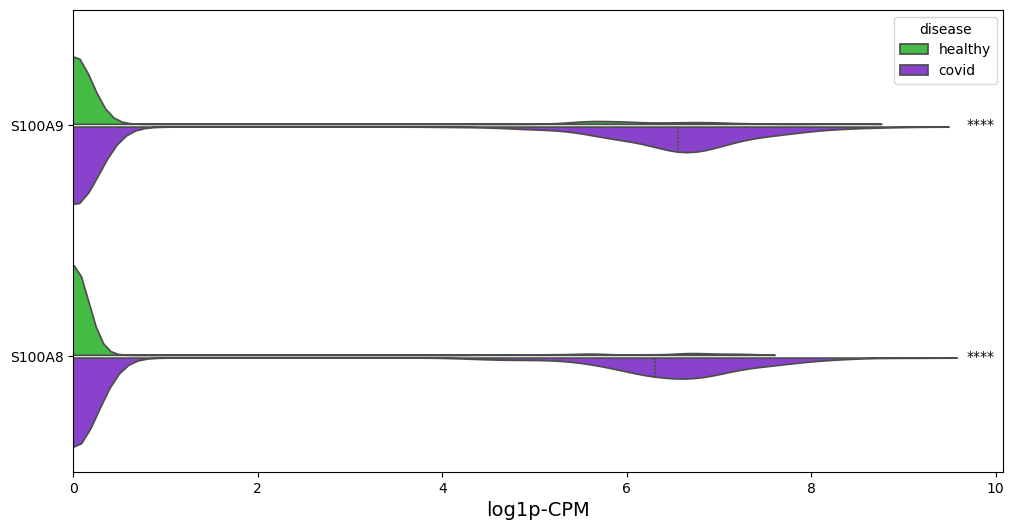

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_D(ax)
# fig.savefig("figures/fortmann-D.svg", bbox_inches="tight", dpi=500)
# fig.savefig("figures/fortmann-D.eps", bbox_inches="tight", dpi=500)
fig.savefig("figures/fortmann-D.pdf", bbox_inches="tight", dpi=500)
plt.show()

## 10. Finale figure

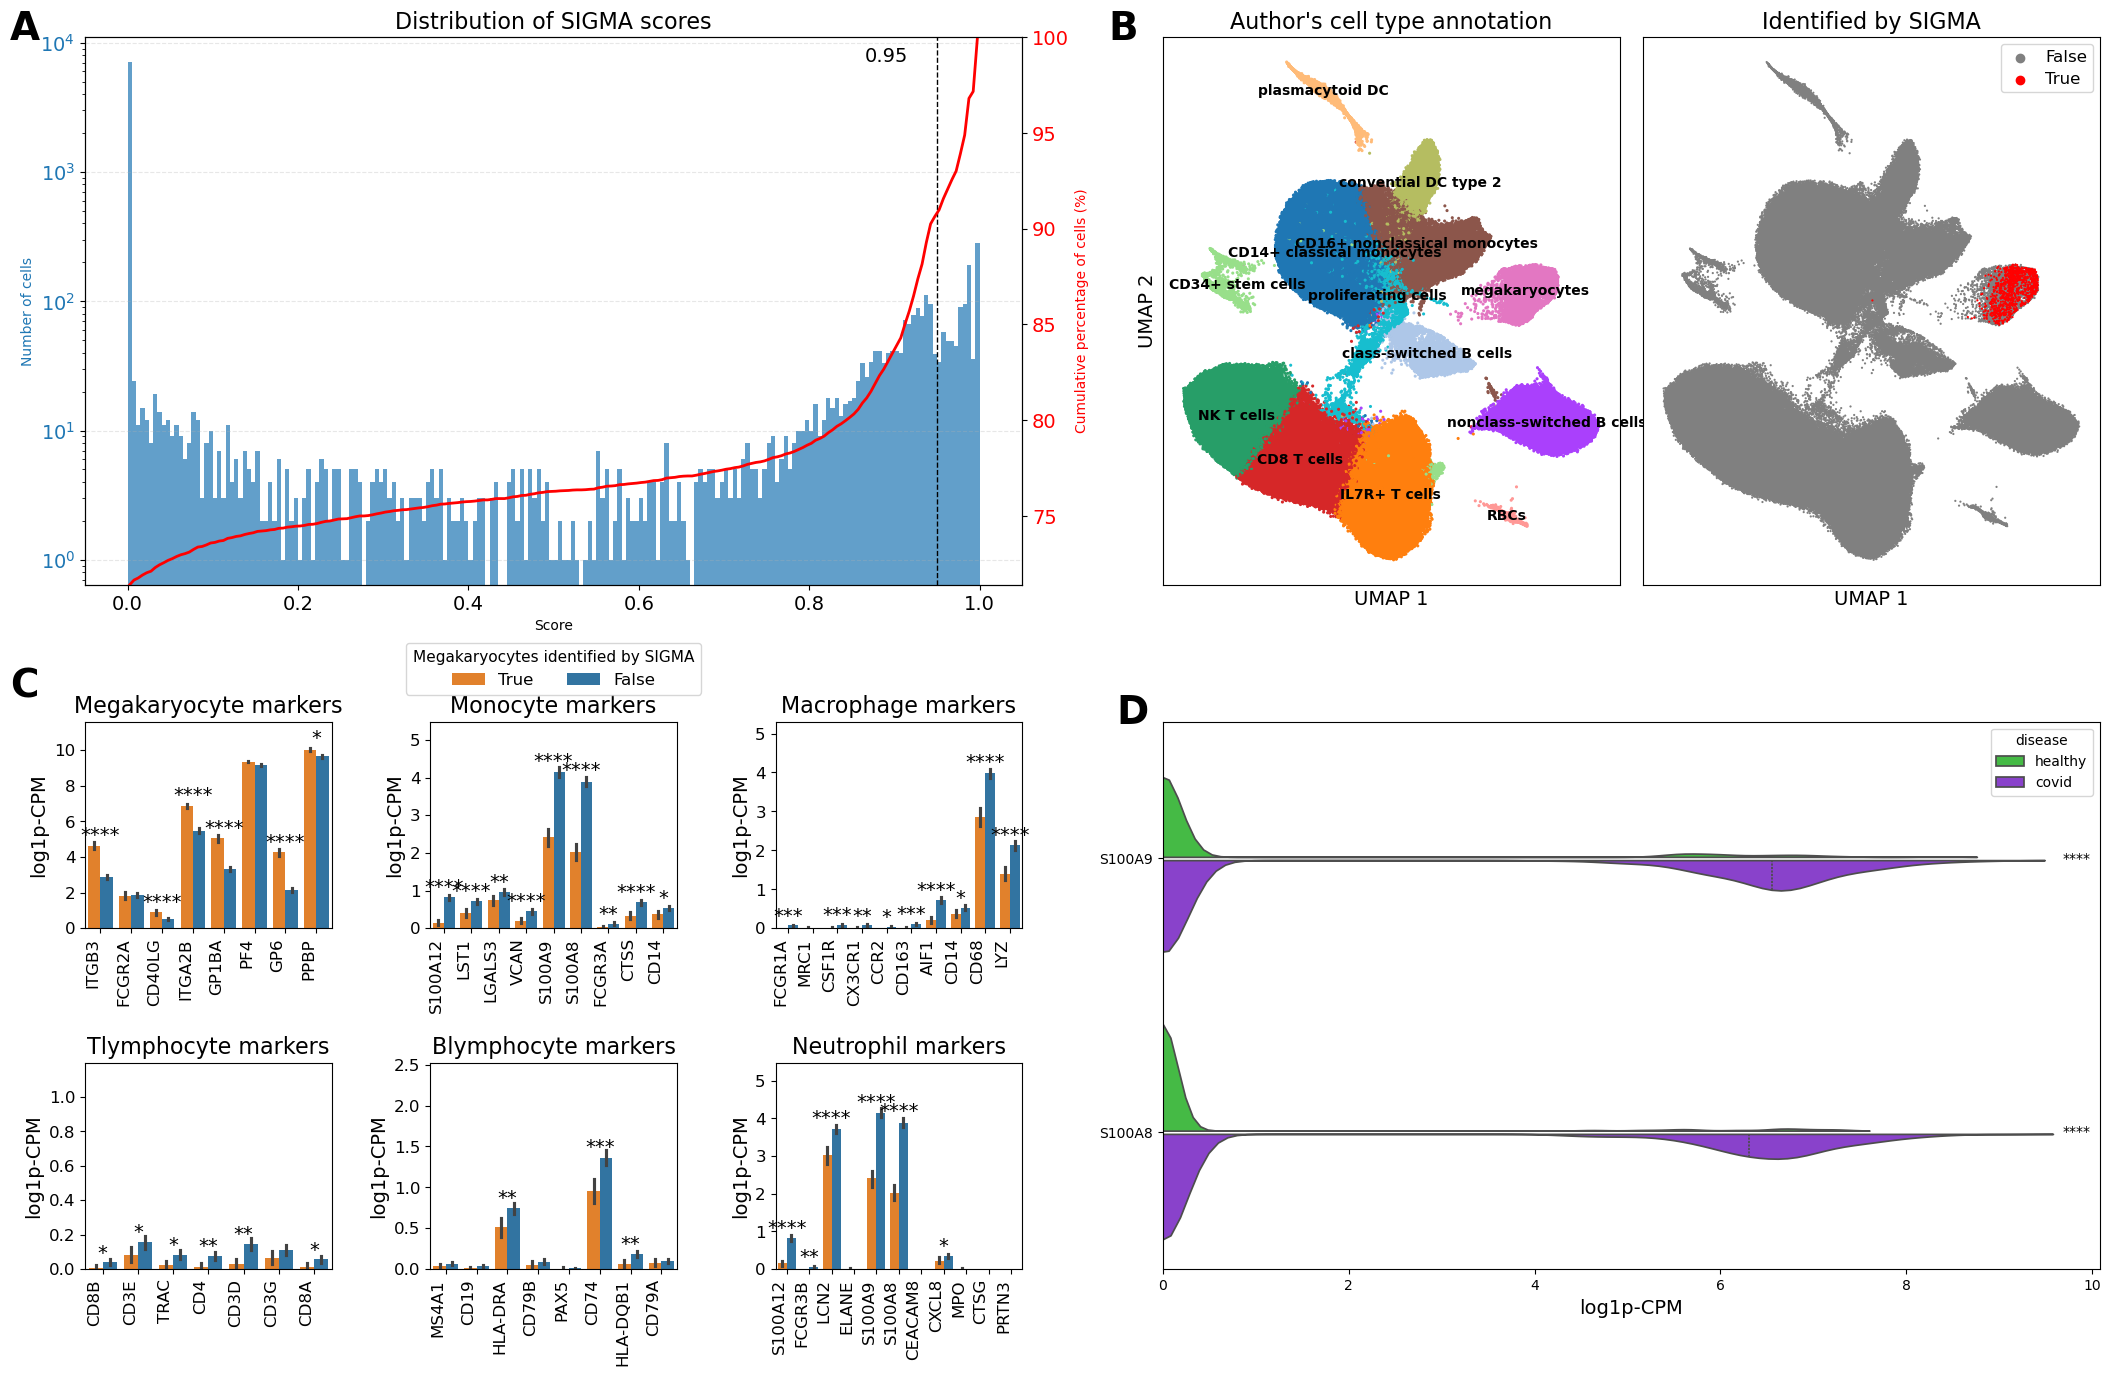

In [20]:
fig = plt.figure(figsize=(26, 16))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.15, height_ratios=[1, 1])

ax_A = fig.add_subplot(gs[0, 0])

gs_B  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0, 1], wspace=0.05)
ax_B0 = fig.add_subplot(gs_B[0])
ax_B1 = fig.add_subplot(gs_B[1])

gs_C = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs[1, 0], hspace=0.65, wspace=0.4, height_ratios=[1, 1])
ax_Cs = [fig.add_subplot(gs_C[i, j]) for i in range(2) for j in range(3)]

ax_D = fig.add_subplot(gs[1, 1])

plot_A(ax_A)
plot_B(ax_B0, ax_B1)
plot_C(ax_Cs, results_C)
plot_D(ax_D)

ax_A.text(-0.08, 1.05, "A", transform=ax_A.transAxes, fontsize=28, fontweight="bold", va="top")
ax_B0.text(-0.12, 1.05, "B", transform=ax_B0.transAxes, fontsize=28, fontweight="bold", va="top")
ax_A.text(-0.08, -0.15, "C", transform=ax_A.transAxes, fontsize=28, fontweight="bold", va="top")
ax_D.text(-0.05, 1.05, "D", transform=ax_D.transAxes, fontsize=28, fontweight="bold", va="top")

# fig.savefig("figures/fortmann-full.svg", bbox_inches="tight", dpi=500)
fig.savefig("figures/fortmann-full.pdf", bbox_inches="tight", dpi=500)
# fig.savefig("figures/fortmann-full.tiff", bbox_inches="tight", dpi=500)
# fig.savefig("figures/fortmann-full.png", bbox_inches="tight", dpi=500)
plt.show()